# Module 1 — Descriptive Statistics & Exploratory Data Analysis

**Statistics Deep Dive · Notebook 1 of 13**

Before we can *infer* anything from data we must be able to *describe* it. Descriptive statistics compress thousands of numbers into a handful of summaries — and every summary throws information away. The art is knowing **which summary is honest for which data**.

### 🎯 Learning goals
After this module you can …
1. classify variables by measurement scale and pick legal summaries for each,
2. compute and interpret measures of **centre** (mean, median, mode, trimmed & geometric mean),
3. compute and interpret measures of **spread** (variance, standard deviation, IQR, MAD, CV),
4. read histograms, KDEs, boxplots and ECDFs — and know how each can mislead,
5. describe **shape** (skewness, kurtosis) and detect **outliers** robustly,
6. explain why you must *always plot your data* (Anscombe's quartet).

### 🗺️ Contents
1. Types of data · 2. Centre · 3. Spread · 4. Quantiles, boxplots & ECDFs · 5. Shape · 6. Histograms & KDEs · 7. Outliers · 8. Always plot your data · 9. Worked example on real data · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

---
## 1. Types of data — what are you allowed to compute?

The **measurement scale** of a variable decides which operations are meaningful. Computing the "mean postcode" is legal Python but statistical nonsense.

| Scale | Meaning | Examples | Meaningful operations | Typical summaries | Typical plots |
|---|---|---|---|---|---|
| **Nominal** | labels, no order | blood type, country, product ID | `=`, `≠` | counts, proportions, mode | bar chart |
| **Ordinal** | ordered labels, unknown spacing | school grades, Likert scale 1–5, T-shirt size | `<`, `>` | median, percentiles, mode | bar chart, ECDF |
| **Interval** | equal spacing, arbitrary zero | °C, calendar year, IQ | `+`, `−` | mean, std | histogram, boxplot |
| **Ratio** | equal spacing, true zero | income, weight, duration, counts | `×`, `÷` ("twice as much") | all of the above, geometric mean, CV | histogram, boxplot |

Nominal + ordinal = **categorical (qualitative)**; interval + ratio = **numerical (quantitative)**. Numerical data is further split into **discrete** (counts) and **continuous** (measurements).

> ⚠️ **Classic trap:** averaging Likert scores (1 = "strongly disagree" … 5 = "strongly agree") assumes the step from 1→2 equals the step from 4→5. Often it does not. Report the median or the full distribution instead.

---
## 2. Measures of centre — "what is a typical value?"

### 2.1 Mean, median, mode

| Measure | Definition | Strength | Weakness |
|---|---|---|---|
| **Arithmetic mean** | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ | uses every observation; algebraically convenient; minimises $\sum (x_i - c)^2$ | dragged by outliers and skew |
| **Median** | middle value of the sorted data (50th percentile) | robust: up to 50 % of the data can be garbage; minimises $\sum \lvert x_i - c\rvert$ | ignores *how far* values are from the centre |
| **Mode** | most frequent value / highest peak | works for nominal data; reveals multi-modality | unstable for continuous data |

**💡 Intuition.** The mean is the **balance point** of the data (put a weight at each value on a ruler — the ruler balances at $\bar{x}$). The median is the **half-way point in headcount**: half of the observations lie on each side, no matter how far away they are.

> 🤔 **Predict first:** for yearly incomes in a country, which is larger — mean or median? Why? Then run the next cell.

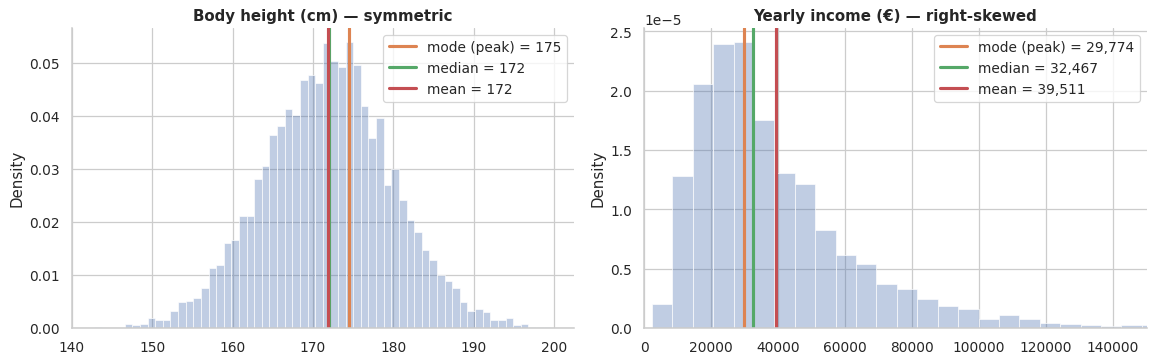

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
heights = rng.normal(172, 8, 5000)            # symmetric: body height (cm)
incomes = rng.lognormal(10.4, 0.6, 5000)      # right-skewed: yearly income (€)

for ax, x, name in zip(axes, [heights, incomes], ["Body height (cm) — symmetric", "Yearly income (€) — right-skewed"]):
    sns.histplot(x, bins=60, ax=ax, color=C[0], alpha=.35, stat="density")
    counts, edges = np.histogram(x, bins=60)
    mode = edges[counts.argmax()] + np.diff(edges)[0] / 2             # centre of the tallest bin
    for val, lab, col in [(mode, "mode (peak)", C[1]), (np.median(x), "median", C[2]), (x.mean(), "mean", C[3])]:
        ax.axvline(val, color=col, lw=2.5, label=f"{lab} = {val:,.0f}")
    ax.set_title(name); ax.legend()
axes[1].set_xlim(0, 150_000)
plt.tight_layout(); plt.show()

**Reading the figure.** For symmetric data all three measures coincide — it does not matter which one you report. For right-skewed data the long tail pulls the mean to the right: **mode < median < mean**. A newspaper writing "the average income is €39k" describes a person richer than roughly 60 % of the population.

### 2.2 How fragile is the mean? — "A billionaire walks into a bar"

Nine guests sit in a bar. A tenth guest enters. We vary the newcomer's income from €30k to €1bn and watch both summaries.

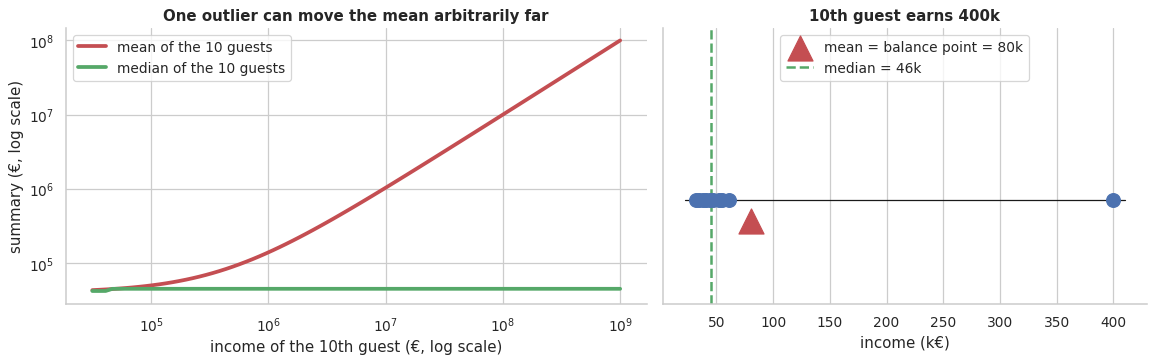

In [3]:
bar = np.array([32, 35, 38, 41, 44, 47, 52, 55, 61.]) * 1000      # incomes of the 9 regulars
newcomer = np.logspace(4.5, 9, 80)                                # income of guest no. 10
means   = [np.append(bar, g).mean()     for g in newcomer]
medians = [np.median(np.append(bar, g)) for g in newcomer]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})
a1.plot(newcomer, means, color=C[3], lw=3, label="mean of the 10 guests")
a1.plot(newcomer, medians, color=C[2], lw=3, label="median of the 10 guests")
a1.set(xscale="log", yscale="log", xlabel="income of the 10th guest (€, log scale)", ylabel="summary (€, log scale)",
       title="One outlier can move the mean arbitrarily far")
a1.legend()

# the 'balance point' picture for one concrete case
x = np.append(bar, 400_000) / 1000
a2.scatter(x, np.zeros_like(x), s=120, color=C[0], zorder=3)
a2.plot([x.min() - 10, x.max() + 10], [0, 0], color="k", lw=1)
a2.scatter([x.mean()], [-0.06], marker="^", s=400, color=C[3], label=f"mean = balance point = {x.mean():.0f}k")
a2.axvline(np.median(x), color=C[2], ls="--", lw=2, label=f"median = {np.median(x):.0f}k")
a2.set(ylim=(-.3, .5), yticks=[], xlabel="income (k€)", title="10th guest earns 400k")
a2.legend(loc="upper center")
plt.tight_layout(); plt.show()

The median barely moves (its **breakdown point** is 50 %), the mean follows the outlier without limit (breakdown point 0 %).

### 2.3 Two more means you will need

* **Trimmed mean** — drop the lowest and highest $k\,\%$, average the rest. A compromise between mean and median (used e.g. in figure-skating scores and in the "core inflation" of some central banks): `stats.trim_mean(x, 0.1)`.
* **Geometric mean** $\left(\prod x_i\right)^{1/n}$ — the right average for **growth factors and ratios**. A fund that gains 50 % and then loses 50 % has an *arithmetic* mean return of 0 %, but you actually end up with $1.5 \times 0.5 = 0.75$ of your money. The geometric mean tells the truth: $\sqrt{1.5 \cdot 0.5} - 1 = -13.4\,\%$ per year.

In [4]:
factors = np.array([1.50, 0.50])                      # +50 % then −50 %
print(f"arithmetic mean return: {factors.mean() - 1:+.1%}   (misleading)")
print(f"geometric  mean return: {stats.gmean(factors) - 1:+.1%}   (what your account really did per year)")
print(f"check: 1000 € -> {1000 * factors.prod():.0f} €  =  1000 × (1 {stats.gmean(factors) - 1:+.3f})²")

arithmetic mean return: +0.0%   (misleading)
geometric  mean return: -13.4%   (what your account really did per year)
check: 1000 € -> 750 €  =  1000 × (1 -0.134)²


---
## 3. Measures of spread — "how different are the values from each other?"

Two datasets can share the same centre and still tell completely different stories. A river that is "on average 1 m deep" can drown you.

| Measure | Formula | Units | Robust? | Comment |
|---|---|---|---|---|
| **Range** | $\max - \min$ | same as data | ✗✗ | determined by the two most extreme points only |
| **Variance** | $s^2 = \frac{1}{n-1}\sum (x_i-\bar{x})^2$ | squared units | ✗ | mathematically central (variances of independent variables add) |
| **Standard deviation** | $s = \sqrt{s^2}$ | same as data | ✗ | "typical distance from the mean" |
| **IQR** | $Q_3 - Q_1$ | same as data | ✓ | width of the middle 50 % |
| **MAD** | $\operatorname{median}(\lvert x_i - \operatorname{median}(x)\rvert)$ | same as data | ✓✓ | most robust; $1.4826\cdot\text{MAD} \approx \sigma$ for normal data |
| **CV** | $s / \bar{x}$ | unit-free | ✗ | compares variability across different scales (ratio data only) |

> **Why $n-1$?** The deviations are measured from $\bar{x}$, which was itself fitted to the data and therefore sits "too close" to the points. Dividing by $n-1$ (Bessel's correction) removes this bias. We will *prove this by simulation* in Module 5. In code: `np.var(x)` divides by $n$ (population), `np.var(x, ddof=1)` and `pandas .var()` divide by $n-1$ (sample).

### 3.1 Seeing the variance: the average squared deviation

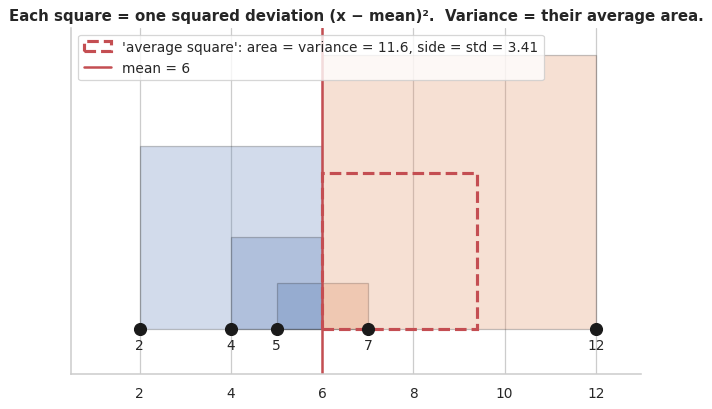

In [5]:
x = np.array([2, 4, 5, 7, 12.]); m = x.mean(); s2 = x.var(ddof=0)
fig, ax = plt.subplots(figsize=(10, 5))
for xi in x:
    d = xi - m
    ax.add_patch(plt.Rectangle((min(xi, m), 0), abs(d), abs(d), color=C[0] if d < 0 else C[1], alpha=.25, ec="k"))
    ax.text(xi, -0.45, f"{xi:.0f}", ha="center", fontsize=11)
ax.add_patch(plt.Rectangle((m, 0), np.sqrt(s2), np.sqrt(s2), fill=False, ec=C[3], lw=2.5, ls="--",
                           label=f"'average square': area = variance = {s2:.1f}, side = std = {np.sqrt(s2):.2f}"))
ax.scatter(x, np.zeros_like(x), s=90, color="k", zorder=3)
ax.axvline(m, color=C[3], lw=2, label=f"mean = {m:.0f}")
ax.set(aspect="equal", ylim=(-1, 6.6), xlim=(0.5, 13), yticks=[],
       title="Each square = one squared deviation (x − mean)².  Variance = their average area.")
ax.legend(loc="upper left"); plt.show()

**Reading the figure.** Points far from the mean produce *disproportionately* large squares — the observation at 12 alone contributes more than half of the total area. This is exactly why variance and standard deviation are sensitive to outliers.

### 3.2 Same centre, different spread

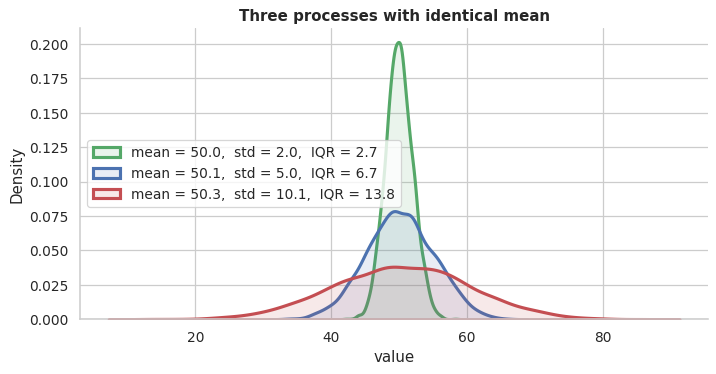

In [6]:
fig, ax = plt.subplots()
for sd, col in zip([2, 5, 10], [C[2], C[0], C[3]]):
    sample = rng.normal(50, sd, 4000)
    sns.kdeplot(sample, ax=ax, color=col, lw=2.5, fill=True, alpha=.12,
                label=f"mean = {sample.mean():.1f},  std = {sample.std(ddof=1):.1f},  IQR = {stats.iqr(sample):.1f}")
ax.set(title="Three processes with identical mean", xlabel="value"); ax.legend(); plt.show()

---
## 4. Quantiles, the five-number summary, boxplots and ECDFs

The **$p$-quantile** $Q(p)$ is the value below which a fraction $p$ of the data lies. Percentiles are quantiles in %, **quartiles** are $Q_1 = Q(0.25)$, $Q_2 = $ median, $Q_3 = Q(0.75)$.

**Five-number summary:** min · $Q_1$ · median · $Q_3$ · max → the **boxplot** draws exactly this, plus Tukey's outlier rule:

$$\text{outlier if } x < Q_1 - 1.5\cdot\text{IQR} \quad\text{or}\quad x > Q_3 + 1.5\cdot\text{IQR}$$

The whiskers end at the most extreme data points that are *not* outliers.

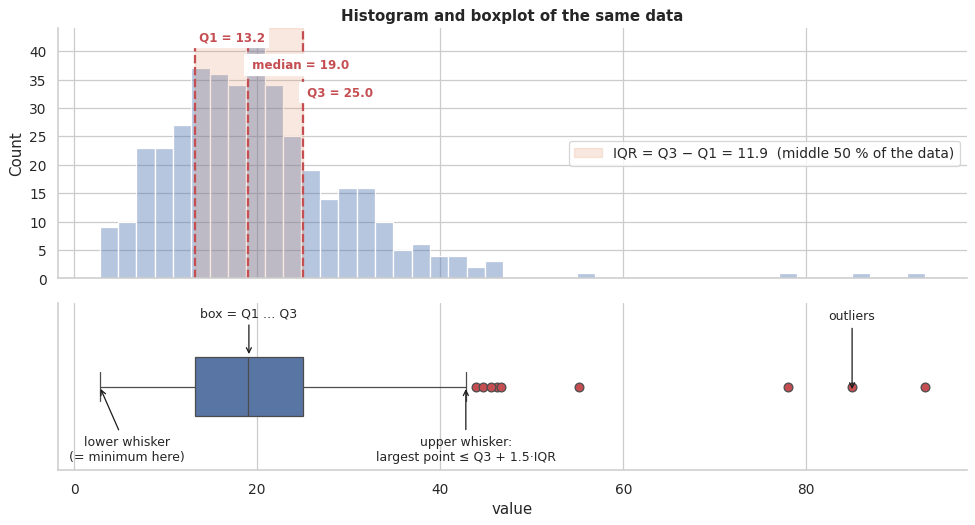

In [7]:
x = np.concatenate([rng.gamma(4, 5, 400), [78, 85, 93]])
q1, med, q3 = np.percentile(x, [25, 50, 75]); iqr = q3 - q1
hi_fence = q3 + 1.5 * iqr; whisk_hi = x[x <= hi_fence].max()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2.4, 1.6]})
sns.histplot(x, bins=45, ax=a1, color=C[0], alpha=.4)
a1.axvspan(q1, q3, color=C[1], alpha=.18, label=f"IQR = Q3 − Q1 = {iqr:.1f}  (middle 50 % of the data)")
for v, l, h in [(q1, "Q1", .99), (med, "median", .88), (q3, "Q3", .77)]:
    a1.axvline(v, color=C[3], ls="--", lw=1.8)
    a1.text(v, a1.get_ylim()[1] * h, f" {l} = {v:.1f}", color=C[3], va="top", fontweight="bold", backgroundcolor="white", fontsize=9.5)
a1.legend(loc="center right"); a1.set_title("Histogram and boxplot of the same data")

sns.boxplot(x=x, ax=a2, color=C[0], width=.35, flierprops=dict(marker="o", markerfacecolor=C[3], markersize=7))
kw = dict(ha="center", fontsize=10, arrowprops=dict(arrowstyle="->", color="k"))
a2.annotate("box = Q1 … Q3", xy=((q1 + q3) / 2, -.18), xytext=((q1 + q3) / 2, -.42), **kw)
a2.annotate("upper whisker:\nlargest point ≤ Q3 + 1.5·IQR", xy=(whisk_hi, 0), xytext=(whisk_hi, .44), **kw)
a2.annotate("outliers", xy=(85, 0.03), xytext=(85, -.4), **kw)
a2.annotate("lower whisker\n(= minimum here)", xy=(x.min(), 0), xytext=(x.min() + 3, .44), **kw)
a2.set(ylim=(.5, -.5), xlabel="value"); plt.tight_layout(); plt.show()

### The ECDF — the most honest plot you are not using

The **empirical cumulative distribution function** $\hat F(x) = \frac{\#\{x_i \le x\}}{n}$ shows *every* data point, needs **no tuning parameter** (no bins!), and lets you read any percentile directly. It is the plot of choice for service-level questions: *"what response time do 95 % of requests achieve?"*

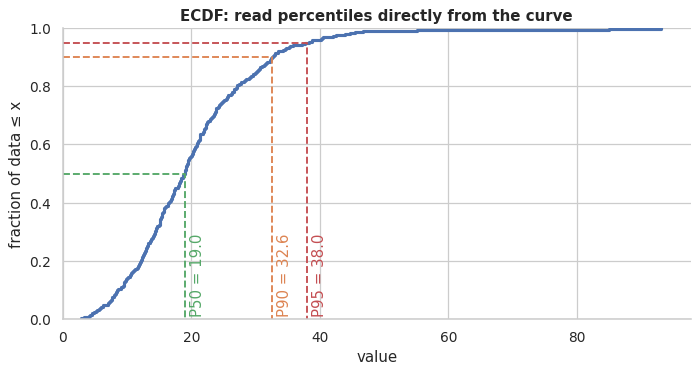

In [8]:
fig, ax = plt.subplots()
sns.ecdfplot(x, ax=ax, color=C[0], lw=2.5)
for p, col in [(.50, C[2]), (.90, C[1]), (.95, C[3])]:
    v = np.quantile(x, p)
    ax.plot([0, v, v], [p, p, 0], color=col, ls="--"); ax.text(v + .8, .02, f"P{p*100:.0f} = {v:.1f}", color=col, rotation=90)
ax.set(title="ECDF: read percentiles directly from the curve", xlabel="value", ylabel="fraction of data ≤ x", xlim=(0, None))
plt.show()

---
## 5. Shape — skewness and kurtosis

* **Skewness** $g_1 = \frac{1}{n}\sum \left(\frac{x_i-\bar x}{s}\right)^3$ measures **asymmetry**. $g_1 > 0$: long right tail (incomes, waiting times, claim sizes). $g_1 < 0$: long left tail (exam scores on an easy test, age at death).
* **(Excess) kurtosis** $g_2 = \frac{1}{n}\sum \left(\frac{x_i-\bar x}{s}\right)^4 - 3$ measures **tail weight** relative to the normal distribution. $g_2 > 0$ (leptokurtic): more extreme outliers than a normal would produce (daily stock returns!). $g_2 < 0$ (platykurtic): thin tails (uniform). Kurtosis is about *tails*, not "peakedness".

Rule of thumb: $|g_1| < 0.5$ ≈ symmetric · $0.5$–$1$ moderately skewed · $> 1$ highly skewed.

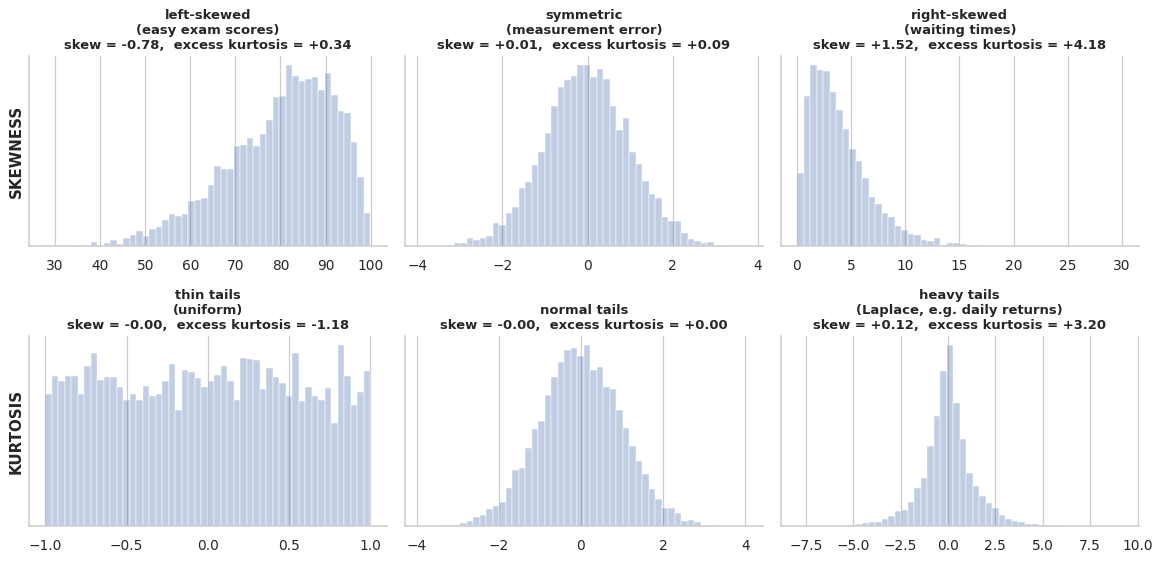

In [9]:
samples = {"left-skewed\n(easy exam scores)":   100 * rng.beta(8, 2, 6000),
           "symmetric\n(measurement error)":    rng.normal(0, 1, 6000),
           "right-skewed\n(waiting times)":     rng.gamma(2, 2, 6000),
           "thin tails\n(uniform)":             rng.uniform(-1, 1, 6000),
           "normal tails":                      rng.normal(0, 1, 6000),
           "heavy tails\n(Laplace, e.g. daily returns)": rng.laplace(0, 1, 6000)}
fig, axes = plt.subplots(2, 3, figsize=(13, 6.4))
for ax, (name, s) in zip(axes.ravel(), samples.items()):
    sns.histplot(s, bins=50, ax=ax, stat="density", color=C[0], alpha=.35)
    ax.set_title(f"{name}\nskew = {stats.skew(s):+.2f},  excess kurtosis = {stats.kurtosis(s):+.2f}", fontsize=10.5)
    ax.set(ylabel="", yticks=[])
axes[0, 0].set_ylabel("SKEWNESS", fontweight="bold"); axes[1, 0].set_ylabel("KURTOSIS", fontweight="bold")
plt.tight_layout(); plt.show()

---
## 6. Histograms & KDEs — powerful, but they have a tuning knob

A histogram's appearance depends on the **bin width**; a kernel density estimate (KDE) depends on the **bandwidth**. Too coarse → you smooth real structure away. Too fine → you see noise. Below: waiting times between eruptions of a geyser-like process with **two modes** — watch the second mode vanish and re-appear.

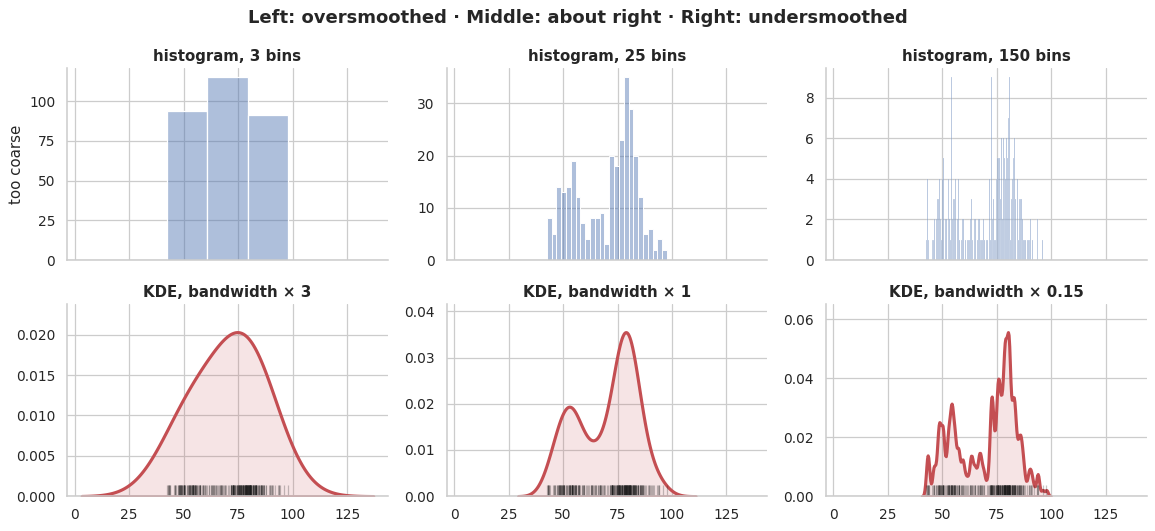

In [10]:
waits = np.concatenate([rng.normal(54, 6, 110), rng.normal(80, 6, 190)])     # bimodal (minutes)
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, b in zip(axes[0], [3, 25, 150]):
    sns.histplot(waits, bins=b, ax=ax, color=C[0], alpha=.45); ax.set_title(f"histogram, {b} bins"); ax.set_ylabel("")
for ax, bw in zip(axes[1], [3, 1, .15]):
    sns.kdeplot(waits, bw_adjust=bw, ax=ax, color=C[3], lw=2.5, fill=True, alpha=.15)
    sns.rugplot(waits, ax=ax, color="k", alpha=.25, height=.06)
    ax.set_title(f"KDE, bandwidth × {bw}"); ax.set_ylabel("")
axes[0, 0].set_ylabel("too coarse"); fig.suptitle("Left: oversmoothed · Middle: about right · Right: undersmoothed", fontweight="bold")
plt.tight_layout(); plt.show()

**Practical advice:** try several bin widths; `bins="fd"` (Freedman–Diaconis rule, $h = 2\cdot\text{IQR}\cdot n^{-1/3}$) is a good robust default. When in doubt, add a rug plot or use the ECDF, which has no knob at all.

---
## 7. Outliers — detect them, *then think*

An outlier is an observation that is surprisingly far from the rest. It may be an **error** (sensor glitch, typo → fix/remove), or the **most interesting data point you have** (fraud, a failing machine, a Nobel prize). Never delete outliers automatically.

| Rule | Flag if … | Problem |
|---|---|---|
| z-score | $\lvert x_i - \bar x\rvert / s > 3$ | $\bar x$ and $s$ are themselves inflated by the outliers → **masking** |
| Tukey / IQR | outside $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$ | flags ~0.7 % of perfectly normal data; too aggressive for skewed data |
| robust z (MAD) | $\lvert x_i - \text{median}\rvert / (1.4826\cdot\text{MAD}) > 3.5$ | best general-purpose choice |

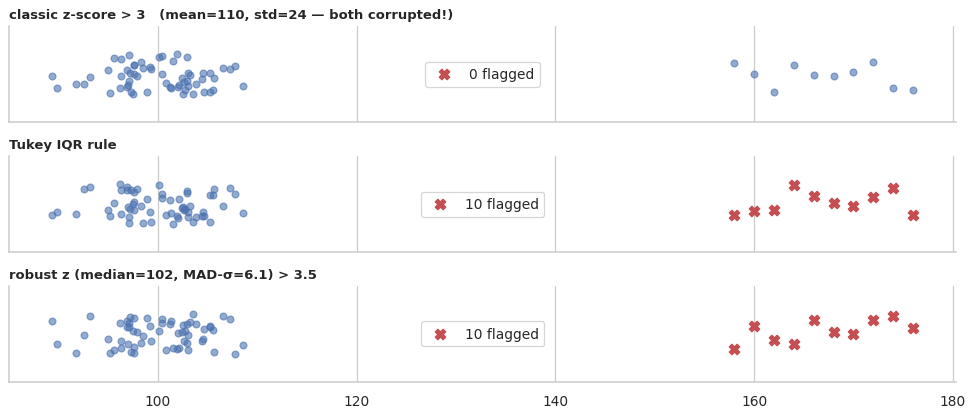

In [11]:
clean = rng.normal(100, 5, 60)
data = np.concatenate([clean, [158, 160, 162, 164, 166, 168, 170, 172, 174, 176]])   # 10 gross errors (14 % contamination)

z      = np.abs(data - data.mean()) / data.std(ddof=1)
q1, q3 = np.percentile(data, [25, 75]); iqr = q3 - q1
mad    = stats.median_abs_deviation(data, scale="normal")             # already multiplied by 1.4826
flags = {f"classic z-score > 3   (mean={data.mean():.0f}, std={data.std(ddof=1):.0f} — both corrupted!)": z > 3,
         "Tukey IQR rule": (data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr),
         f"robust z (median={np.median(data):.0f}, MAD-σ={mad:.1f}) > 3.5": np.abs(data - np.median(data)) / mad > 3.5}

fig, axes = plt.subplots(3, 1, figsize=(11, 4.8), sharex=True)
for ax, (name, f) in zip(axes, flags.items()):
    jitter = rng.uniform(-.25, .25, len(data))
    ax.scatter(data[~f], jitter[~f], color=C[0], alpha=.6, s=30)
    ax.scatter(data[f], jitter[f], color=C[3], s=70, marker="X", label=f"{f.sum()} flagged")
    ax.set(yticks=[], ylim=(-.6, .6)); ax.set_title(name, fontsize=10.5, loc="left"); ax.legend(loc="center")
plt.tight_layout(); plt.show()

**Masking in action:** the ten gross errors drag the mean upwards and inflate the standard deviation from 5 to well over 20. Measured with this corrupted yardstick, even a reading of 176 has a z-score *below 3* — the classic rule finds **nothing**. Median and MAD are hardly affected by the contamination, so the robust rule (and the IQR rule) flag all ten.

---
## 8. Always plot your data — Anscombe's quartet

Four datasets, constructed by the statistician Francis Anscombe (1973). Look at the summary statistics first …

In [12]:
x123 = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
quartet = {"I":   (x123, [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
           "II":  (x123, [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
           "III": (x123, [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
           "IV":  ([8] * 7 + [19] + [8] * 3, [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])}
pd.DataFrame({k: {"mean x": np.mean(x), "mean y": np.mean(y), "var x": np.var(x, ddof=1), "var y": np.var(y, ddof=1),
                  "corr(x, y)": np.corrcoef(x, y)[0, 1]} for k, (x, y) in quartet.items()}).T.round(2)

,mean x,mean y,var x,var y,"corr(x, y)"
I,9.0,7.5,11.0,4.13,0.82
II,9.0,7.5,11.0,4.13,0.82
III,9.0,7.5,11.0,4.12,0.82
IV,9.0,7.5,11.0,4.12,0.82


Identical to two decimals. Now the plots:

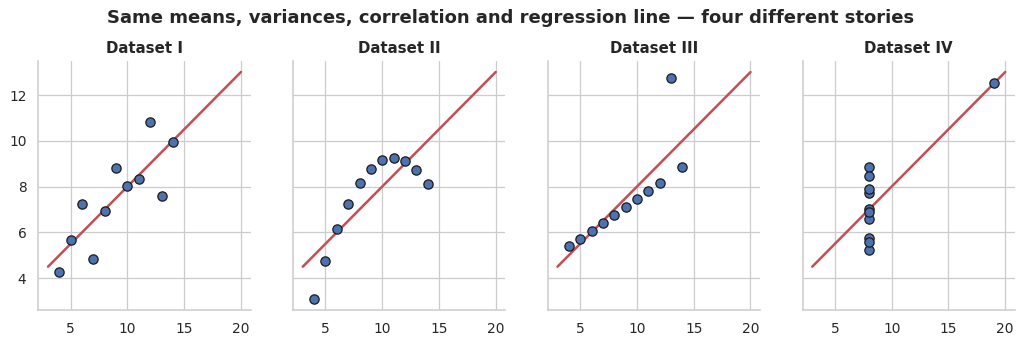

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True, sharey=True)
for ax, (k, (x, y)) in zip(axes, quartet.items()):
    ax.scatter(x, y, s=55, color=C[0], edgecolor="k", zorder=3)
    b1, b0 = np.polyfit(x, y, 1); xx = np.array([3, 20]); ax.plot(xx, b0 + b1 * xx, color=C[3], lw=2)
    ax.set_title(f"Dataset {k}")
fig.suptitle("Same means, variances, correlation and regression line — four different stories", fontweight="bold", y=1.04)
plt.show()

I: a well-behaved linear relation · II: a perfect *curve* (a line is the wrong model) · III: a perfect line plus **one outlier** · IV: no relation at all — a single **leverage point** manufactures the correlation. *Summary statistics alone cannot distinguish these cases. Your eyes can.*

---
## 9. Worked example on real data — tumour measurements

The **Wisconsin Breast Cancer** dataset (shipped with scikit-learn) contains measurements of cell nuclei from 569 biopsies, labelled benign or malignant. Question: *how does the mean nucleus radius differ between the two groups?*

In [14]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True)
df = bc.frame[["mean radius", "mean texture", "mean concavity"]].copy()
df["diagnosis"] = bc.target.map({0: "malignant", 1: "benign"})

summary = df.groupby("diagnosis")["mean radius"].agg(
    n="count", mean="mean", median="median", std="std", IQR=stats.iqr, skew=stats.skew,
    P5=lambda s: s.quantile(.05), P95=lambda s: s.quantile(.95)).round(2)
summary

,n,mean,median,std,IQR,skew,P5,P95
diagnosis,,,,,,,,
benign,357,12.15,12.20,1.78,2.29,-0.08,9.04,14.93
malignant,212,17.46,17.33,3.20,4.51,0.50,12.80,23.14


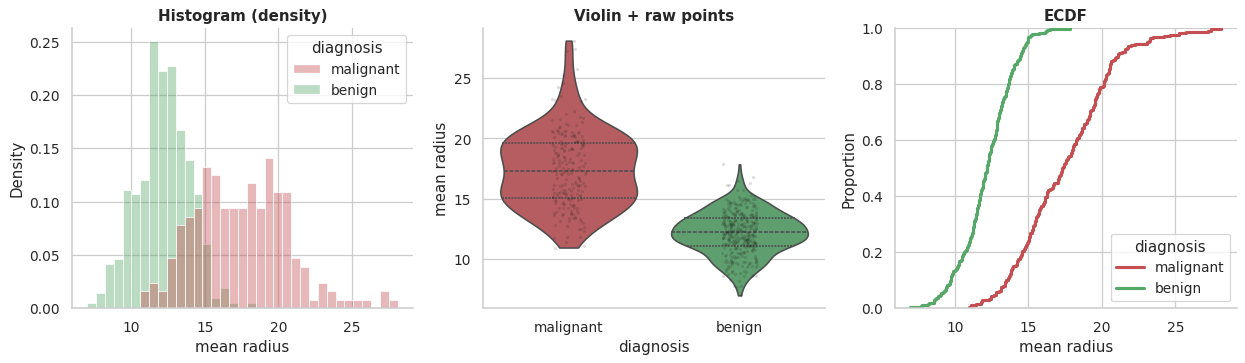

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
pal = {"benign": C[2], "malignant": C[3]}
sns.histplot(df, x="mean radius", hue="diagnosis", palette=pal, bins=35, stat="density", common_norm=False, ax=axes[0], alpha=.4)
sns.violinplot(df, x="diagnosis", y="mean radius", palette=pal, inner="quartile", ax=axes[1], cut=0)
sns.stripplot(df, x="diagnosis", y="mean radius", color="k", alpha=.15, size=2.5, ax=axes[1])
sns.ecdfplot(df, x="mean radius", hue="diagnosis", palette=pal, lw=2.5, ax=axes[2])
for ax, t in zip(axes, ["Histogram (density)", "Violin + raw points", "ECDF"]): ax.set_title(t)
plt.tight_layout(); plt.show()

**How a statistician would report this.** Malignant tumours have clearly larger nuclei (median radius 17.3 vs 12.2) *and* are more variable (IQR 4.5 vs 2.3). The benign distribution is fairly symmetric; the malignant one is slightly right-skewed. The ECDF shows that a radius of ≈15 separates the groups well: about 96 % of benign but only about 24 % of malignant tumours lie below it. Whether this difference is "statistically significant" is a question for Module 6 — but with a gap this large, the picture already says it all.

---
## 10. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 1.1 — *Centre*: What salary should the job ad quote? (HR analytics)

You are a people-analytics analyst at a 400-person software company. Marketing wants to write *"average salary: € …"* into a job ad. The data contains all salaries, including a handful of executives.

**Tasks**
1. Compute mean, median, 10 %-trimmed mean and mode (use €5k bins) of `salaries`.
2. Plot the distribution and mark mean and median.
3. What share of employees earns *less* than the mean?
4. Which number would you put into the ad, and how would you phrase it honestly?
5. Remove the 8 executives and recompute mean and median. What do you observe?

In [16]:
g = np.random.default_rng(101)
staff      = g.lognormal(mean=np.log(62_000), sigma=0.25, size=392)
executives = g.uniform(250_000, 900_000, size=8)
salaries = pd.Series(np.round(np.concatenate([staff, executives]), -2), name="salary_eur")
salaries.describe().round(0)

count       400.0
mean      72642.0
std       73840.0
min       27400.0
25%       51275.0
50%       62400.0
75%       74725.0
max      853100.0
Name: salary_eur, dtype: float64

In [17]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/01_descriptive_statistics_solutions.ipynb`.

### ✍️ Exercise 1.2 — *Spread*: Which courier can promise "delivered within 48 h"? (Logistics)

An online shop compares two couriers. Both advertise "average delivery time: 36 hours". The shop wants to promise customers **delivery within 48 h** and accepts that at most 5 % of parcels break the promise.

**Tasks**
1. Compare mean, std, IQR, CV and the 95th percentile of both couriers.
2. Visualise both distributions in one figure (boxplot *and* ECDF).
3. What fraction of parcels arrives later than 48 h for each courier? Which courier do you choose?
4. What delivery promise (in hours) could each courier keep for 95 % of parcels?

In [18]:
g = np.random.default_rng(102)
deliveries = pd.DataFrame({"courier": ["SwiftShip"] * 800 + ["ParcelPal"] * 800,
                           "hours": np.concatenate([g.normal(36, 4, 800), 18 + g.gamma(2.0, 9.0, 800)])})
deliveries.groupby("courier").hours.mean().round(1)

courier
ParcelPal    36.5
SwiftShip    35.7
Name: hours, dtype: float64

In [19]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/01_descriptive_statistics_solutions.ipynb`.

### ✍️ Exercise 1.3 — *Outliers*: Cleaning a cold-chain temperature log (IoT / quality assurance)

A pharma warehouse logs the temperature of a vaccine fridge every 5 minutes (target 2–8 °C). The sensor occasionally produces glitches (readings like 85 °C or −40 °C). QA must report mean temperature and variability — a single accepted glitch would ruin the report, a wrongly deleted *real* excursion could hide a safety problem.

**Tasks**
1. Plot the time series. What do you see?
2. Flag outliers with (a) the classic z-score rule (|z| > 3) and (b) the robust MAD rule (> 3.5). How many points does each rule flag, and *which kind* of anomaly does each find?
3. The log also contains a *real* event (a door left open around reading 1200–1230). Which rule sees it? Why does the other one miss it?
4. Report mean ± std for (i) the raw log, (ii) after deleting everything the robust rule flags, (iii) after deleting only physically impossible values (outside −10 … 50 °C). Which version belongs in the QA report?

In [20]:
g = np.random.default_rng(103)
n = 2016                                                       # one week of 5-minute readings
temp = 5 + 0.6 * np.sin(np.arange(n) * 2 * np.pi / 288) + g.normal(0, 0.35, n)
temp[1200:1230] += np.linspace(0, 4.5, 30)                     # real event: door left open, temperature climbs
glitch_idx = g.choice(n, 25, replace=False)
temp[glitch_idx] = g.choice([85.0, -40.0, 127.0], 25)          # sensor glitches
log = pd.Series(temp, index=pd.date_range("2026-03-02", periods=n, freq="5min"), name="temp_C")
log.describe().round(2)

count    2016.00
mean        5.33
std         7.88
min       -40.00
25%         4.60
50%         5.00
75%         5.44
max       127.00
Name: temp_C, dtype: float64

In [21]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/01_descriptive_statistics_solutions.ipynb`.

### ✍️ Exercise 1.4 — *Full EDA*: Profiling wines from three growers (real data)

A wine cooperative buys grapes from three cultivars. The lab has chemical analyses of 178 wines (`sklearn.datasets.load_wine`). Management asks for a one-page descriptive profile.

**Tasks**
1. For `alcohol`, `color_intensity` and `proline`, compute per cultivar: n, mean, median, std, IQR and skewness.
2. Which variable is the most skewed? Which has the highest *relative* variability (CV)?
3. Create a figure that compares the three cultivars for all three variables (your choice of plot — justify it).
4. Write three sentences for management: what distinguishes the cultivars?

In [22]:
from sklearn.datasets import load_wine
w = load_wine(as_frame=True)
wine = w.frame[["alcohol", "color_intensity", "proline"]].copy()
wine["cultivar"] = w.target.map({0: "A", 1: "B", 2: "C"})
wine.head()

,alcohol,color_intensity,proline,cultivar
0,14.23,5.64,1065.0,A
1,13.20,4.38,1050.0,A
2,13.16,5.68,1185.0,A
3,14.37,7.80,1480.0,A
4,13.24,4.32,735.0,A


In [23]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/01_descriptive_statistics_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* The measurement scale determines which summaries are meaningful.
* **Mean** = balance point (efficient, fragile). **Median** = headcount midpoint (robust). For skewed data report the median — or both.
* Always pair a measure of centre with a **measure of spread**; risk and service levels live in the **tails**.
* Standard deviation squares the deviations → outliers dominate. IQR and MAD are robust alternatives.
* Histograms/KDEs have a tuning knob — try several settings; the ECDF has none.
* Outlier rules based on mean/std suffer from **masking** — use median/MAD. Flag automatically, delete only with a reason.
* **Always plot your data** (Anscombe). Summary statistics are lossy compression.

### Cheat sheet
| Task | Code |
|---|---|
| all-in-one summary | `df.describe()`, `df.groupby(g).agg([...])` |
| mean / median / trimmed / geometric | `x.mean()`, `np.median(x)`, `stats.trim_mean(x, .1)`, `stats.gmean(x)` |
| std, variance (sample) | `np.std(x, ddof=1)`, `np.var(x, ddof=1)` · pandas uses `ddof=1` by default |
| IQR / MAD | `stats.iqr(x)`, `stats.median_abs_deviation(x, scale="normal")` |
| quantiles | `np.quantile(x, [.05, .5, .95])`, `s.quantile(.95)` |
| skewness / kurtosis | `stats.skew(x)`, `stats.kurtosis(x)` (excess) |
| plots | `sns.histplot`, `sns.kdeplot`, `sns.boxplot`, `sns.violinplot`, `sns.ecdfplot` |

**Next:** Module 2 — Probability, the language in which uncertainty is written.